# Denoising Images present in CIFAR-10 data set

We will start with the CIFAR-10 data set but this time we will introduce some random noise in each of the images. To initiate, let us read the images in the environment:

## Installing Packages

In [16]:
%pip install pandas numpy matplotlib tensorflow keras pillow # Pillow is required for image processing


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Importing basic libraries

In [17]:
import pandas as pd # Data manipulation and analysis
import numpy as np # Numerical operations
import matplotlib.pyplot as plt # Plotting library
from PIL import Image # Image processing library
import os # Operating system interface
from tensorflow.keras.datasets import cifar10 # Using TensorFlow to download / load CIFAR-10 dataset
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D # Keras layers for building the model
from keras.models import Model # Keras model class for building the autoencoder

## Loading dataset

In [18]:
# This will download the dataset if not already present
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

## Reading

In [19]:
# Reading all the image dataset present in numpy array format
img_arr = x_train[:150] / 255.0 # Normalizing the pixel values to [0, 1] range
print(img_arr.shape)

(150, 32, 32, 3)


## Adding Noise

We have used only 150 CIFAR-10 dataset images and stored all of these 32x32x3 dimensional images to a numpy array. Now, we add noise to each of these images:

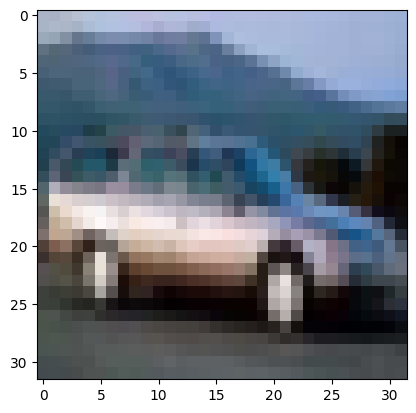

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16696562249371275..1.1288791250380146].


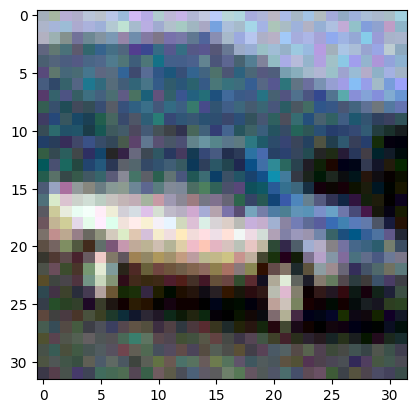

In [20]:
# Original image
plt.imshow(img_arr[4])
plt.show()

# Adding random noise to the images
noise_factor = 0.05
noisy_imgs = img_arr + noise_factor * np.random.normal(size=img_arr.shape)
# Image with noise
plt.imshow(noisy_imgs[4])
plt.show()

# Auto-Encoders

Now let's understand the main topic / concept behind this.

An auto-encoder is:

- part of unsupervised learning in the neural network domain
- non-linear
- helps in applications like
    - data compression
    - image denoising
    - watermark removal from images
    - etc ...

Their applications are similar to that of PCA (Principal Component Analysis) except the fact that PCA works with linear transformation and auto-encoders are based on non-linear transformation.

An auto-encoder as the name suggests is made up of two modules as described below:

- **Encoder:** This module helps in breaking down the input into a smaller size (often compresses it) into something named as latent-space ( maximum compression one can) and bottleneck which illustrates the point of maximum compression. The compression which takes place isn't the lossless rather lossy which means that the reconstructed image in the output will not be exactly the same bits by bits as the provided input.

- **Decoder:** This module helps to decode the encoded input from the latent-space. If the decoder is able to reconstruct almost a similar image as the input then you can consider the model as robust. However, auto-encoders are data specific, therefore, if you train it on the data set of flowers and assume it to work on the vehicles data set then you'd receive wrong results.

## Basic architecture of an auto-encoder

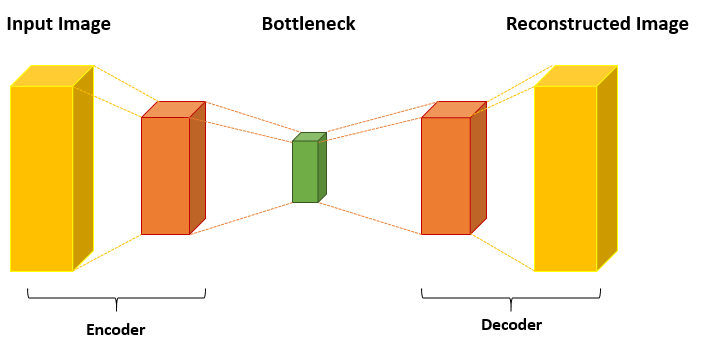

There are various auto-encoders based on their applications in use like convolutional, sparse, contractive, and as usual deep auto-encoders.

## Designing the encoder

In encoding module, we have first 2 downsampling layers with filters 32 and 64, followed by a final layer with 128 filters.
<br>
In the decoding module, we have 128 and 64 filters in the first 2 upsampling layers followed by a final softmax layer with 3 nodes (representing each color channel - R G B).

In [21]:
def auto_encoder(img):
    # Encoder module
    f_size = 3 # filter size
    p_size = 1 # pool size
    conv_1 = Conv2D(32, (f_size, f_size), activation='relu', padding='same')(img)
    pool_1 = MaxPooling2D(pool_size=(p_size, p_size))(conv_1) 
    conv_2 = Conv2D(64, (f_size, f_size), activation='relu', padding='same')(pool_1)
    pool_2 = MaxPooling2D(pool_size=(p_size, p_size))(conv_2) 
    conv_3 = Conv2D(128, (f_size, f_size), activation='relu', padding='same')(pool_2) 
    # Decoder module
    conv_4 = Conv2D(128, (f_size, f_size), activation='relu', padding='same')(conv_3) 
    up_1 = UpSampling2D((p_size, p_size))(conv_4) 
    conv_5 = Conv2D(64, (f_size, f_size), activation='relu', padding='same')(up_1) 
    up_2 = UpSampling2D((p_size, p_size))(conv_5) 
    decoded = Conv2D(3, (f_size, f_size), activation='sigmoid', padding='same')(up_2) 
    return decoded

## Call, Compile, Train

In [22]:
# Calling the network design function and compiling the model
img = Input(shape=(32, 32, 3))
model = Model(img, auto_encoder(img))
model.compile(loss='mean_squared_error', optimizer='adam')
# Training the model
model.fit(noisy_imgs[:120], img_arr[:120], epochs=10, validation_split=0.2)

Epoch 1/10


2025-06-17 09:18:01.899653: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-06-17 09:18:04.174704: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 16777216 exceeds 10% of free system memory.
2025-06-17 09:18:04.254766: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 16777216 exceeds 10% of free system memory.
2025-06-17 09:18:04.447305: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33030144 exceeds 10% of free system memory.
2025-06-17 09:18:04.512048: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 28311552 exceeds 10% of free system memory.
2025-06-17 09:18:04.531449: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 16777216 exceeds 10% of free system memory.


3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.0593 - val_loss: 0.0642
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.0531 - val_loss: 0.0513
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0420 - val_loss: 0.0446
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.0405 - val_loss: 0.0307
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0327 - val_loss: 0.0259
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0253 - val_loss: 0.0221
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.0215 - val_loss: 0.0197
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0177 - val_loss: 0.0171
Epoch 9/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.0169 - val_loss: 0.0155
Epoch 10/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - loss: 0.0143 - val_loss: 0.0153


## Prediction on test, train

In [23]:
pred = model.predict(img_arr)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step


## Train Data Prediction

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16696562249371275..1.1288791250380146].


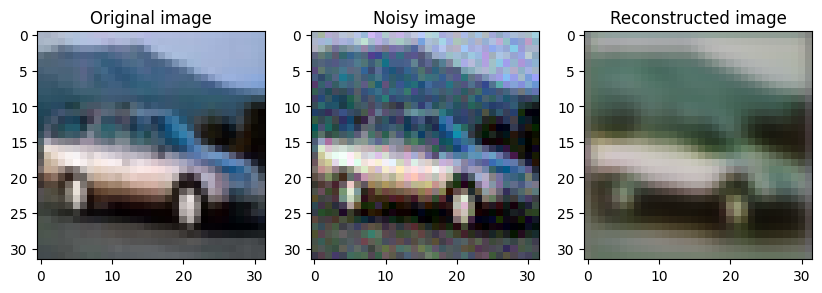

In [24]:
plt.figure(figsize=(10, 5))
ax1 = plt.subplot2grid((1, 3), (0,0))
ax1.set_title('Original image', fontsize='large')
ax1.imshow(img_arr[4])
ax2 = plt.subplot2grid((1, 3), (0,1))
ax2.set_title('Noisy image', fontsize='large')
ax2.imshow(noisy_imgs[4])
ax3 = plt.subplot2grid((1, 3), (0,2))
ax3.set_title('Reconstructed image', fontsize='large')
ax3.imshow(pred[4])
plt.show()

## Test Data Prediction

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05515551685823583..1.1358276822429465].


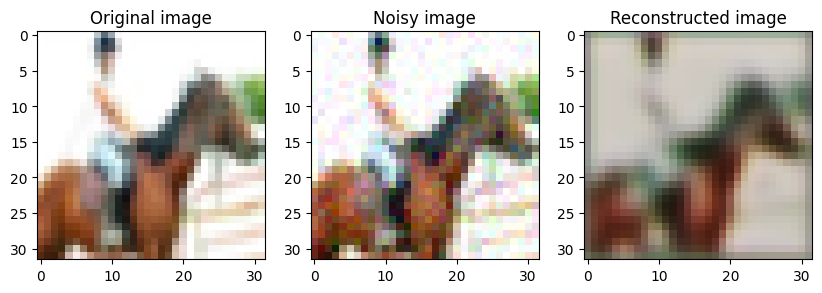

In [25]:
plt.figure(figsize=(10, 5))
ax1 = plt.subplot2grid((1, 3), (0,0))
ax1.set_title('Original image', fontsize='large')
ax1.imshow(img_arr[131])
ax2 = plt.subplot2grid((1, 3), (0,1))
ax2.set_title('Noisy image', fontsize='large')
ax2.imshow(noisy_imgs[131])
ax3 = plt.subplot2grid((1, 3), (0,2))
ax3.set_title('Reconstructed image', fontsize='large')
ax3.imshow(pred[131])
plt.show()

As we can observe the given auto-encoder design has provided darker results. That's why it is recommended to always set the optimal hyperparameters before you finalize the model because accuracy is not that good for complex datasets and models.

Go to the next file to check improved version with the optimal hyperparameters